In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FILE = "Business_Analytics_Practice_Dataset_STUDENT.xlsx"
SHEET = "S9_Trend_Interpretation"


## Step 1 — Load the monthly data series

In [2]:
df = pd.read_excel(FILE, sheet_name=SHEET, header=2, usecols="A:G")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head(12)


,Month Index,Date,Units Sold,Revenue (RWF),Profit (RWF),Fuel Price (RWF/Litre),Inflation Rate (%)
0,1,2020-01-01,3816,4054000,1437368,1079,6.23
1,2,2020-02-01,4171,4742800,1692022,1116,6.51
2,3,2020-03-01,4254,4919358,1741501,1141,7.17
3,4,2020-04-01,4312,5211282,1838413,1139,5.77
4,5,2020-05-01,4221,4803078,1695065,1147,6.07
5,6,2020-06-01,4240,4842100,1704581,1152,5.08
6,7,2020-07-01,3940,4401000,1540230,1122,4.05
7,8,2020-08-01,3597,3828033,1306847,1132,3.95
8,9,2020-09-01,3622,3916341,1354781,1100,4.57
9,10,2020-10-01,3448,3551800,1214071,1123,4.32


## Step 2 — Calculate MoM %, YoY %, and 3-Month Moving Average

- **Revenue MoM %** = percentage change from the previous month
- **Revenue YoY %** = percentage change vs. the same month one year (12 months) earlier
- **3-Month Moving Avg Revenue** = average of the current month and the 2 preceding months (smooths short-term noise)


In [3]:
df["Revenue MoM %"]  = df["Revenue (RWF)"].pct_change(1) * 100
df["Revenue YoY %"]  = df["Revenue (RWF)"].pct_change(12) * 100
df["3-Month Moving Avg Revenue"] = df["Revenue (RWF)"].rolling(window=3).mean()

df[["Date", "Revenue (RWF)", "Revenue MoM %", "Revenue YoY %", "3-Month Moving Avg Revenue"]].round(2).tail(15)


/tmp/ipykernel_605/1620899828.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df[["Date", "Revenue (RWF)", "Revenue MoM %", "Revenue YoY %", "3-Month Moving Avg Revenue"]].round(2).tail(15)


,Date,Revenue (RWF),Revenue MoM %,Revenue YoY %,3-Month Moving Avg Revenue
45,2023-10-01,5355112,0.69,33.78,5464894.33
46,2023-11-01,5349522,-0.10,19.11,5341038.67
47,2023-12-01,5033257,-5.91,3.91,5245963.67
48,2024-01-01,6443140,28.01,19.00,5608639.67
49,2024-02-01,6779630,5.22,9.62,6085342.33
50,2024-03-01,7145793,5.40,10.73,6789521.00
51,2024-04-01,7733048,8.22,9.14,7219490.33
52,2024-05-01,7458158,-3.55,11.08,7445666.33
53,2024-06-01,6596150,-11.56,8.28,7262452.00
54,2024-07-01,6632670,0.55,13.57,6895659.33


## Step 2b — (Optional) Export the completed calculations back to Excel format (columns H, I, J)

In [4]:
out = df.copy()
out.to_excel("S9_completed_calculations.xlsx", index=False)
print("Saved: S9_completed_calculations.xlsx")


Saved: S9_completed_calculations.xlsx


## Step 3 — Plot the revenue trend

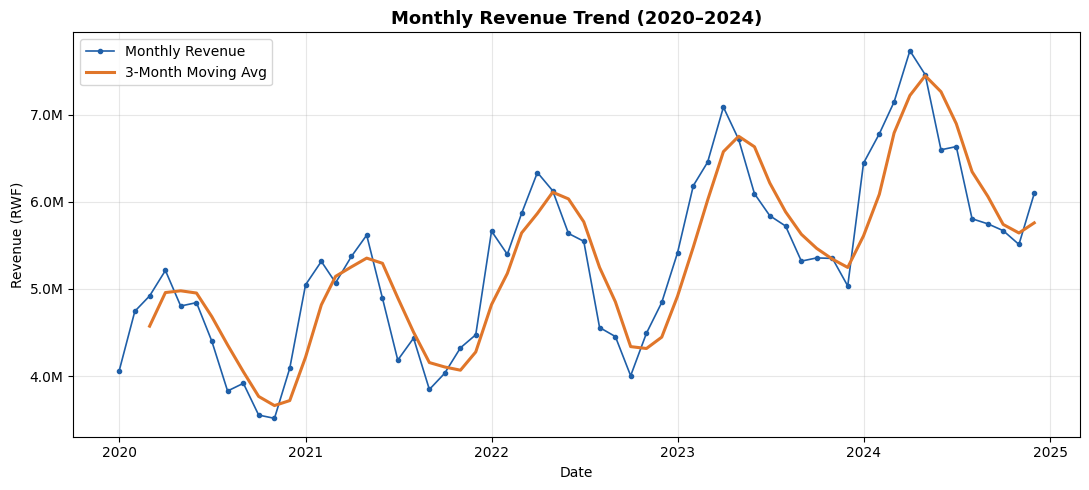

In [5]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["Revenue (RWF)"], marker="o", markersize=3, linewidth=1.2, label="Monthly Revenue", color="#1f5fa8")
ax.plot(df["Date"], df["3-Month Moving Avg Revenue"], linewidth=2.2, label="3-Month Moving Avg", color="#e0762a")

ax.set_title("Monthly Revenue Trend (2020–2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (RWF)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.savefig("revenue_trend_chart.png", dpi=150)
plt.show()


## Step 4 — Visualize MoM % and YoY % change

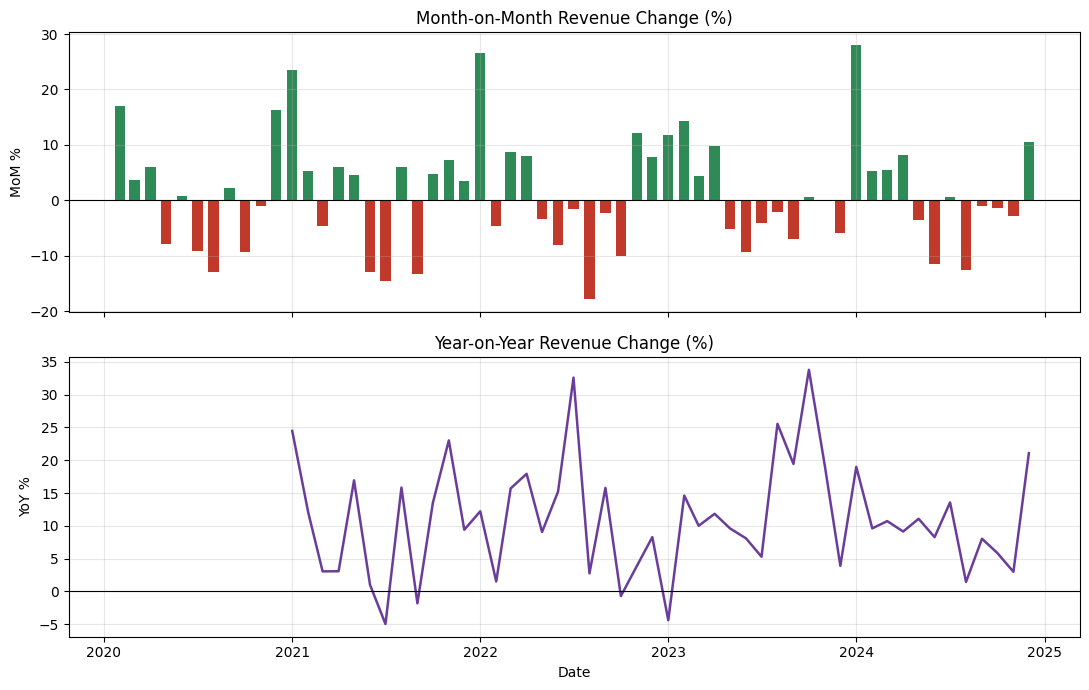

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].bar(df["Date"], df["Revenue MoM %"], width=20, color=np.where(df["Revenue MoM %"] >= 0, "#2e8b57", "#c0392b"))
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Month-on-Month Revenue Change (%)")
axes[0].set_ylabel("MoM %")

axes[1].plot(df["Date"], df["Revenue YoY %"], color="#6a3d9a", linewidth=1.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Year-on-Year Revenue Change (%)")
axes[1].set_ylabel("YoY %")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("mom_yoy_chart.png", dpi=150)
plt.show()


## Step 5 — Identify high/low performing periods and seasonality

In [7]:
print("TOP 5 highest-revenue months:")
print(df.nlargest(5, "Revenue (RWF)")[["Date", "Revenue (RWF)"]].to_string(index=False))

print("\nTOP 5 lowest-revenue months:")
print(df.nsmallest(5, "Revenue (RWF)")[["Date", "Revenue (RWF)"]].to_string(index=False))

print("\nBiggest single-month jumps (MoM %):")
print(df.nlargest(5, "Revenue MoM %")[["Date", "Revenue MoM %"]].round(2).to_string(index=False))

print("\nBiggest single-month drops (MoM %):")
print(df.nsmallest(5, "Revenue MoM %")[["Date", "Revenue MoM %"]].round(2).to_string(index=False))

# Average revenue by calendar month, across all 5 years -> reveals seasonality
df["MonthName"] = df["Date"].dt.strftime("%b")
df["MonthNum"] = df["Date"].dt.month
seasonal = df.groupby(["MonthNum", "MonthName"])["Revenue (RWF)"].mean().reset_index().sort_values("MonthNum")
print("\nAverage revenue by calendar month (seasonality pattern):")
print(seasonal[["MonthName", "Revenue (RWF)"]].round(0).to_string(index=False))


TOP 5 highest-revenue months:
      Date  Revenue (RWF)
2024-04-01        7733048
2024-05-01        7458158
2024-03-01        7145793
2023-04-01        7085583
2024-02-01        6779630

TOP 5 lowest-revenue months:
      Date  Revenue (RWF)
2020-11-01        3514200
2020-10-01        3551800
2020-08-01        3828033
2021-09-01        3845598
2020-09-01        3916341

Biggest single-month jumps (MoM %):
      Date  Revenue MoM %
2024-01-01          28.01
2022-01-01          26.59
2021-01-01          23.43
2020-02-01          16.99
2020-12-01          16.34

Biggest single-month drops (MoM %):
      Date  Revenue MoM %
2022-08-01         -17.84
2021-07-01         -14.49
2021-09-01         -13.28
2020-08-01         -13.02
2021-06-01         -12.91

Average revenue by calendar month (seasonality pattern):
MonthName  Revenue (RWF)
      Jan      5324147.0
      Feb      5683684.0
      Mar      5890968.0
      Apr      6347438.0
      May      6143637.0
      Jun      5611466.0
      Jul

/tmp/ipykernel_605/3502732877.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df.nlargest(5, "Revenue MoM %")[["Date", "Revenue MoM %"]].round(2).to_string(index=False))
/tmp/ipykernel_605/3502732877.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df.nsmallest(5, "Revenue MoM %")[["Date", "Revenue MoM %"]].round(2).to_string(index=False))


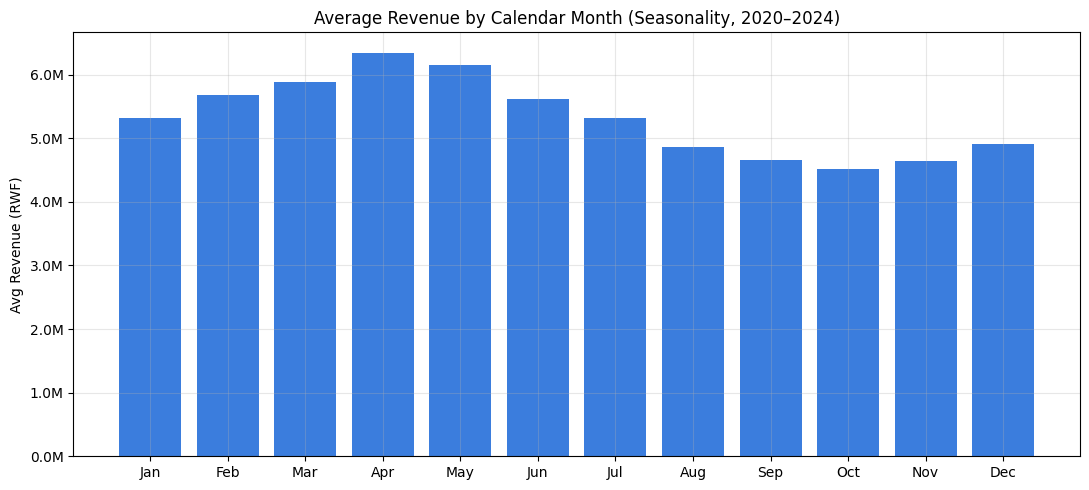

In [8]:
fig, ax = plt.subplots()
ax.bar(seasonal["MonthName"], seasonal["Revenue (RWF)"], color="#3b7ddd")
ax.set_title("Average Revenue by Calendar Month (Seasonality, 2020–2024)")
ax.set_ylabel("Avg Revenue (RWF)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("seasonality_chart.png", dpi=150)
plt.show()


## Step 6 — Relate revenue to economic indicators (fuel price & inflation)

In [9]:
corr = df[["Revenue (RWF)", "Fuel Price (RWF/Litre)", "Inflation Rate (%)"]].corr().round(2)
corr


,Revenue (RWF),Fuel Price (RWF/Litre),Inflation Rate (%)
Revenue (RWF),1.00,0.79,0.55
Fuel Price (RWF/Litre),0.79,1.00,0.38
Inflation Rate (%),0.55,0.38,1.00


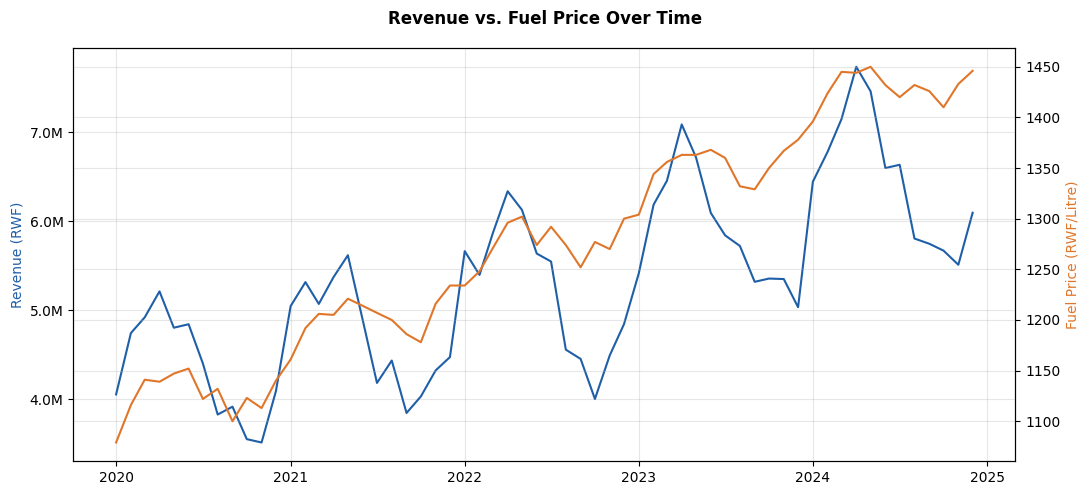

In [10]:
fig, ax1 = plt.subplots()
ax1.plot(df["Date"], df["Revenue (RWF)"], color="#1f5fa8", label="Revenue")
ax1.set_ylabel("Revenue (RWF)", color="#1f5fa8")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Fuel Price (RWF/Litre)"], color="#e0762a", label="Fuel Price")
ax2.set_ylabel("Fuel Price (RWF/Litre)", color="#e0762a")

fig.suptitle("Revenue vs. Fuel Price Over Time", fontweight="bold")
plt.tight_layout()
plt.savefig("revenue_vs_fuel.png", dpi=150)
plt.show()


## Step 7 — Year-over-year growth summary

In [11]:
yearly = df.groupby(df["Date"].dt.year)["Revenue (RWF)"].mean().round(0)
yearly_growth = yearly.pct_change().round(4) * 100
summary = pd.DataFrame({"Avg Monthly Revenue": yearly, "YoY Growth %": yearly_growth})
summary


,Avg Monthly Revenue,YoY Growth %
Date,,
2020,4322708.0,NaN
2021,4716853.0,9.12
2022,5242963.0,11.15
2023,5880150.0,12.15
2024,6467660.0,9.99


## Step 8 Interpretation Questions & Answers

*(These answers correspond to the "Interpretation questions" column (L) in the `S9_Trend_Interpretation` worksheet.)*

### Q1. What changed over time?
Revenue shows a **clear long-term upward trend** combined with a **repeating seasonal (annual) cycle**. Average monthly revenue rose from about **RWF 4.32M in 2020** to about **RWF 6.47M in 2024** — roughly **50% growth over five years**. Layered on top of that growth, every year follows the same up-and-down pattern: revenue rises from January, peaks around March–May, then declines through the middle of the year to a trough around September–October, before recovering toward December/January.

### Q2. By how much did revenue change?
- **Overall (Jan 2020 → Dec 2024):** revenue grew about **+50%** (from ~RWF 4.05M to ~RWF 6.09M in single-month terms; ~50% on the annual averages).
- **Year-over-year (average annual growth):** roughly **+9% to +12%** per year (2021: +9%, 2022: +11%, 2023: +12%, 2024: +10%).
- **Month-to-month swings:** typically **±5–10%**, with the biggest single-month jumps around **+24% to +28%** (Jan 2021, Jan 2022, Jan 2024 — the seasonal upswing) and the sharpest drops around **‑13% to ‑18%** (Jun–Aug of most years — the seasonal downswing).

### Q3. Which months show high/low performance?
- **High-performing months:** **March, April, and May** consistently show the highest revenue each year (the 5 all-time highest months are all Feb–May 2023/2024).
- **Low-performing months:** **August, September, and October** are consistently the weakest, with the lowest revenue months on record falling in **Oct–Nov 2020** and **Aug–Sep 2021**.
- This is a **recurring seasonal pattern**, not random noise — it shows up every single year in the data.

### Q4. What possible economic factor might explain it?
Several factors likely combine to drive this pattern:
- **Seasonality tied to the local business/agricultural calendar** — a Q1–Q2 peak and a Q3 trough is consistent with harvest/planting cycles, school-term timing, or festive/holiday spending common in Rwanda, which would lift demand for goods and units sold in the first half of the year.
- **Fuel price pass-through** — revenue and fuel price move together fairly strongly (correlation ≈ **0.79**). As fuel costs rise, transport and input costs likely get passed into prices, and fuel price itself often rises alongside broader demand — so fuel price is a useful *leading/coincident indicator* of the revenue cycle.
- **Inflation** — the correlation between revenue and inflation is more moderate (≈ **0.55**), suggesting inflation contributes to nominal revenue growth (higher prices push up RWF revenue even if unit volumes don't grow as fast) but is a smaller driver than the seasonal effect.

### Q5. What business decision should follow?
- **Plan working capital and inventory around the seasonal cycle:** build up stock/staffing ahead of the **Jan–May peak** and avoid over-ordering going into the **Aug–Oct trough**, since the dip is predictable, not a sign of failure.
- **Time promotions and cost control:** run margin-protecting promotions or cost-cutting measures during the seasonal trough (Jul–Oct) rather than the peak, when demand needs no extra push.
- **Watch fuel price and inflation as early-warning signals:** because revenue tracks fuel price closely, a sustained rise in fuel costs is a signal to review pricing/margins proactively rather than reactively.
- **Use the moving average, not single months, for decisions:** because month-to-month swings of ±10–15% are normal seasonal noise, budgeting and target-setting should be based on the **3-month moving average / year-over-year trend**, not any single month's number.


## Step 9  One overall business implication

> The business is **structurally healthy and growing (~10%/year)**, but revenue is **highly seasonal** and **sensitive to fuel/inflation costs**. The right response is not to chase every monthly swing, but to build a **cash-flow and inventory plan around the known seasonal cycle**, and to treat rising fuel prices/inflation as an early signal to review pricing — protecting margin during the low season (Aug–Oct) while maximizing throughput during the high season (Jan–May).
